<a href="https://colab.research.google.com/github/agustincasal1/bank-marketing-icd-2026/blob/main/notebook/Trabajo_Final_ICD_Bank_Marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ====================================================================
# TRABAJO FINAL · ICD 2026 · Bank Marketing Dataset
# Agustín Casal - Teo Martínez - Francisco Medrano - Martina Saldías
# ====================================================================
import warnings
warnings.filterwarnings('ignore')

# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_curve,
    auc, roc_auc_score
)

# Configuración visual
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [ ]:
# Cargar el dataset
df = pd.read_csv('/content/Bank Marketing Dataset_TF.csv')

print(f"✅ Dataset cargado exitosamente")
print(f"   Filas:    {df.shape[0]:,}")
print(f"   Columnas: {df.shape[1]}")
df.head()

✅ Dataset cargado exitosamente
   Filas:    11,162
   Columnas: 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042.0,1.0,-1,0,unknown,yes
1,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,NaN,1.0,-1,0,unknown,yes
2,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389.0,1.0,-1,0,unknown,yes
3,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579.0,1.0,-1,0,unknown,yes
4,54.0,admin.,married,tertiary,no,184,no,no,unknown,5,may,673.0,2.0,-1,0,unknown,yes


In [ ]:
# Tipos de datos y conteo de nulos
print("=== Información del Dataset ===")
df.info()

# Valores nulos por columna
print("\n=== Valores nulos por columna ===")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "No hay valores nulos detectados")

# Estadísticas de columnas numéricas
print("\n=== Estadísticas descriptivas ===")
df.describe().round(2)

=== Información del Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        10828 non-null  float64
 1   job        11162 non-null  object 
 2   marital    11162 non-null  object 
 3   education  11162 non-null  object 
 4   default    11162 non-null  object 
 5   balance    11162 non-null  int64  
 6   housing    11162 non-null  object 
 7   loan       11162 non-null  object 
 8   contact    11162 non-null  object 
 9   day        11162 non-null  int64  
 10  month      11162 non-null  object 
 11  duration   10604 non-null  float64
 12  campaign   10046 non-null  float64
 13  pdays      11162 non-null  int64  
 14  previous   11162 non-null  int64  
 15  poutcome   11162 non-null  object 
 16  deposit    11162 non-null  object 
dtypes: float64(3), int64(4), object(10)
memory usage: 1.4+ MB

=== Valores nulos por columna ===
a

,age,balance,day,duration,campaign,pdays,previous
count,10828.00,11162.00,11162.00,10604.00,10046.00,11162.00,11162.00
mean,41.21,1528.54,15.66,372.67,2.50,51.33,0.83
std,11.90,3225.41,8.42,348.05,2.69,108.76,2.29
min,18.00,-6847.00,1.00,2.00,1.00,-1.00,0.00
25%,32.00,122.00,8.00,138.00,1.00,-1.00,0.00
50%,39.00,550.00,15.00,255.00,2.00,-1.00,0.00
75%,49.00,1708.00,22.00,497.00,3.00,20.75,1.00
max,95.00,81204.00,31.00,3881.00,63.00,854.00,58.00


In [ ]:
# Distribución de la variable objetivo: ¿suscribió depósito?
conteo = df['deposit'].value_counts()
pct    = df['deposit'].value_counts(normalize=True) * 100

print("=== Variable objetivo: deposit ===")
print(f"  yes (suscribió):  {conteo['yes']:,} ({pct['yes']:.1f}%)")
print(f"  no  (no suscribió): {conteo['no']:,}  ({pct['no']:.1f}%)")
print(f"\n  Desbalance de clases: {pct['no']/pct['yes']:.1f}:1")

=== Variable objetivo: deposit ===
  yes (suscribió):  5,289 (47.4%)
  no  (no suscribió): 5,873  (52.6%)

  Desbalance de clases: 1.1:1


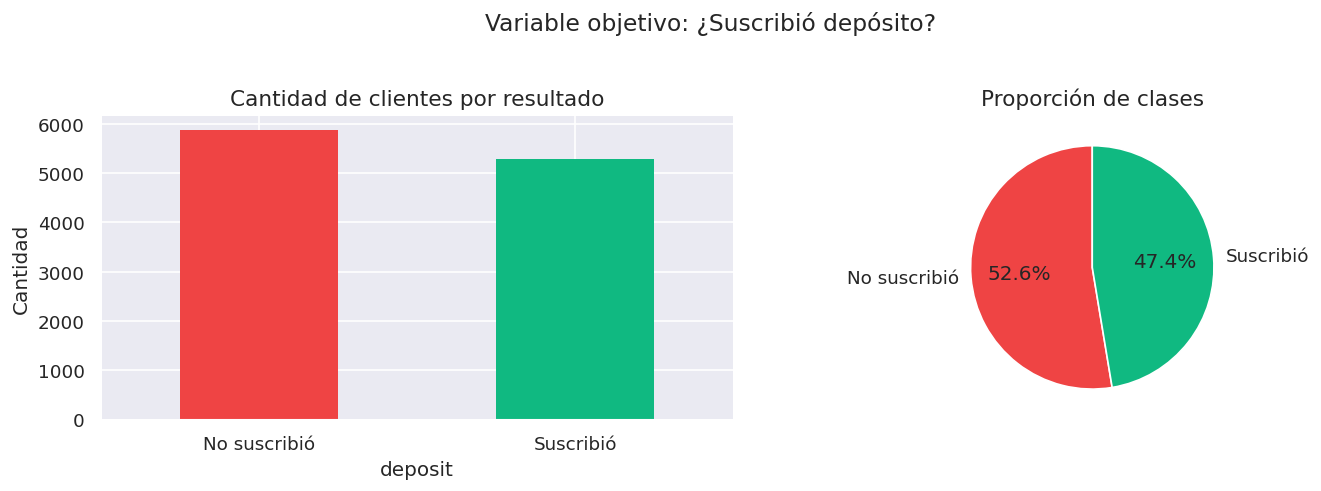

In [ ]:
# Gráfico de distribución del target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colores = ['#ef4444', '#10b981']

# Barras
df['deposit'].value_counts().plot(
    kind='bar', ax=axes[0], color=colores, edgecolor='none', width=0.5
)
axes[0].set_title('Cantidad de clientes por resultado', fontsize=13)
axes[0].set_xticklabels(['No suscribió', 'Suscribió'], rotation=0)
axes[0].set_ylabel('Cantidad')

# Torta
df['deposit'].value_counts().plot(
    kind='pie', ax=axes[1], labels=['No suscribió', 'Suscribió'],
    colors=colores, autopct='%1.1f%%', startangle=90
)
axes[1].set_title('Proporción de clases', fontsize=13)
axes[1].set_ylabel('')

plt.suptitle('Variable objetivo: ¿Suscribió depósito?', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

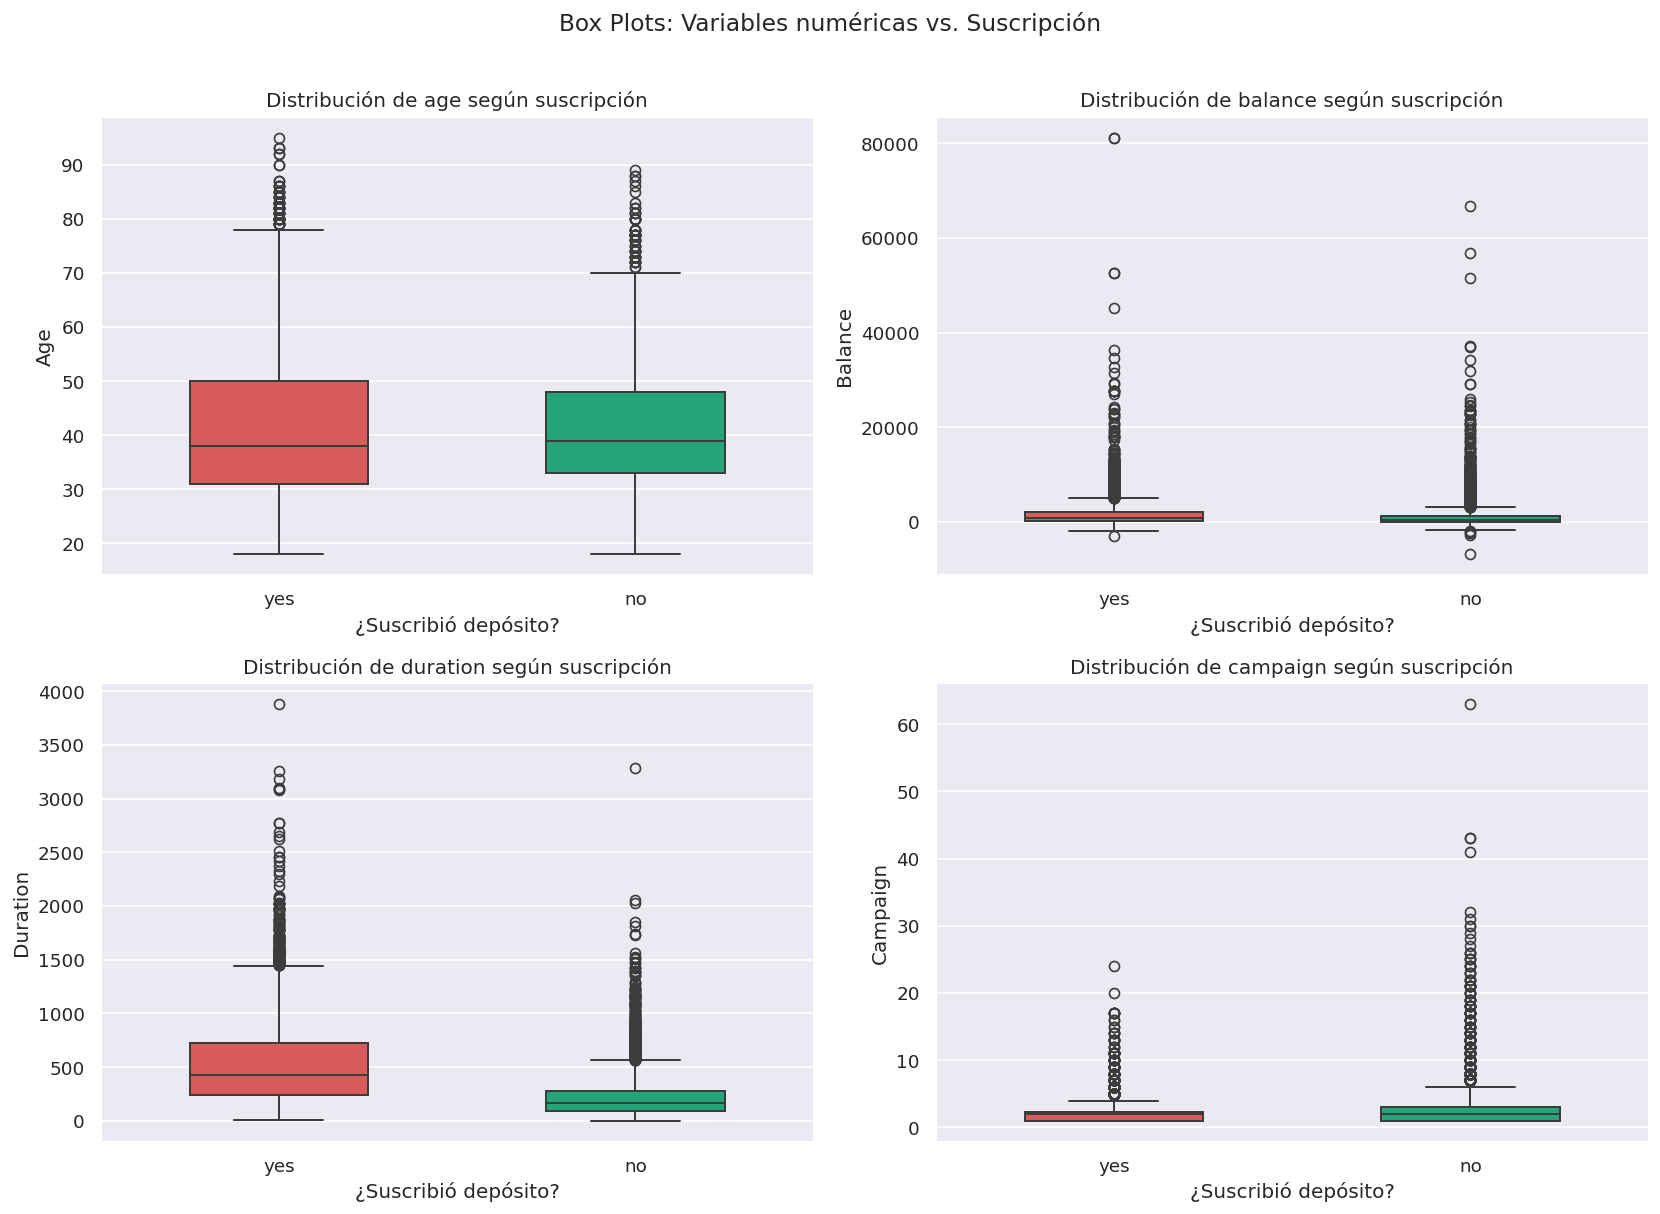

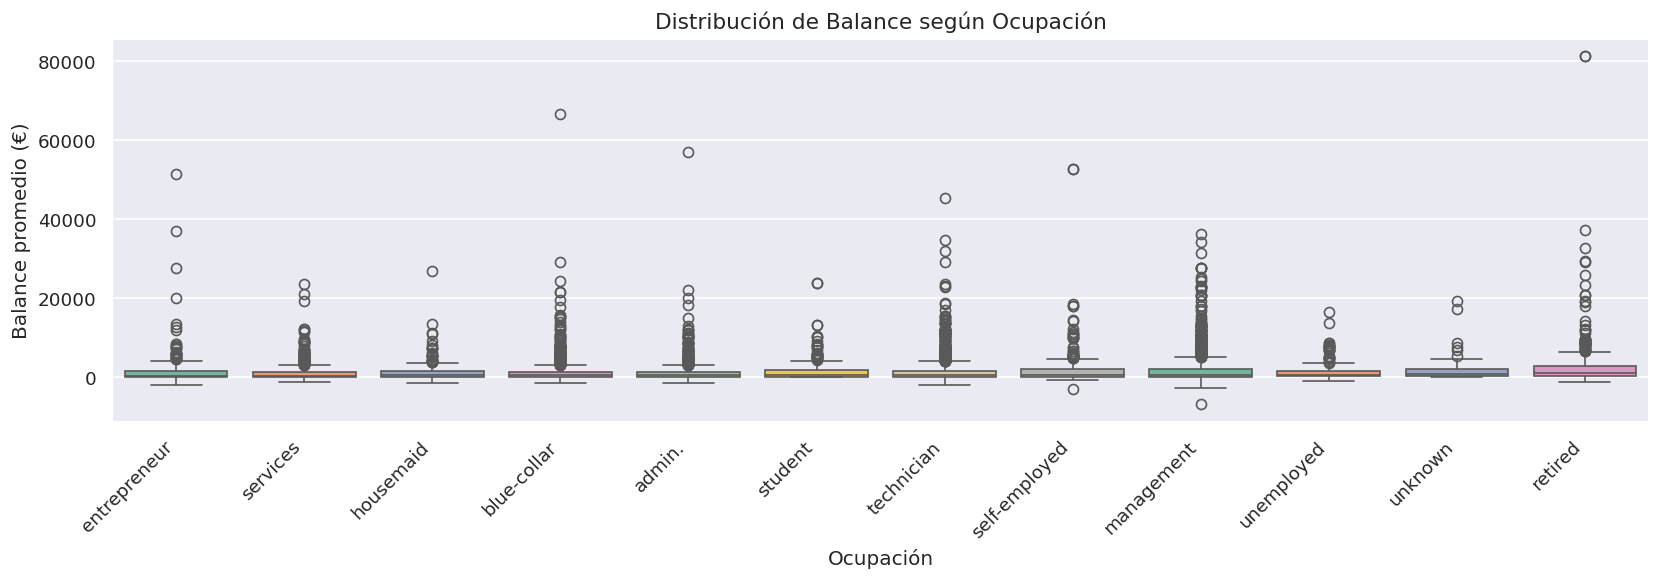

In [ ]:
# Box plots de variables numéricas clave separadas por target
vars_num = ['age', 'balance', 'duration', 'campaign']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(vars_num):
    sns.boxplot(
        data=df, x='deposit', y=var,
        palette=['#ef4444', '#10b981'],
        ax=axes[i], width=0.5, linewidth=1.2
    )
    axes[i].set_title(f'Distribución de {var} según suscripción', fontsize=12)
    axes[i].set_xlabel('¿Suscribió depósito?')
    axes[i].set_ylabel(var.capitalize())

plt.suptitle('Box Plots: Variables numéricas vs. Suscripción', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Box plot adicional: balance por job
plt.figure(figsize=(14, 5))
order = df.groupby('job')['balance'].median().sort_values().index
sns.boxplot(data=df, x='job', y='balance',
            palette='Set2', order=order)
plt.xticks(rotation=45, ha='right')
plt.title('Distribución de Balance según Ocupación', fontsize=13)
plt.xlabel('Ocupación')
plt.ylabel('Balance promedio (€)')
plt.tight_layout()
plt.show()

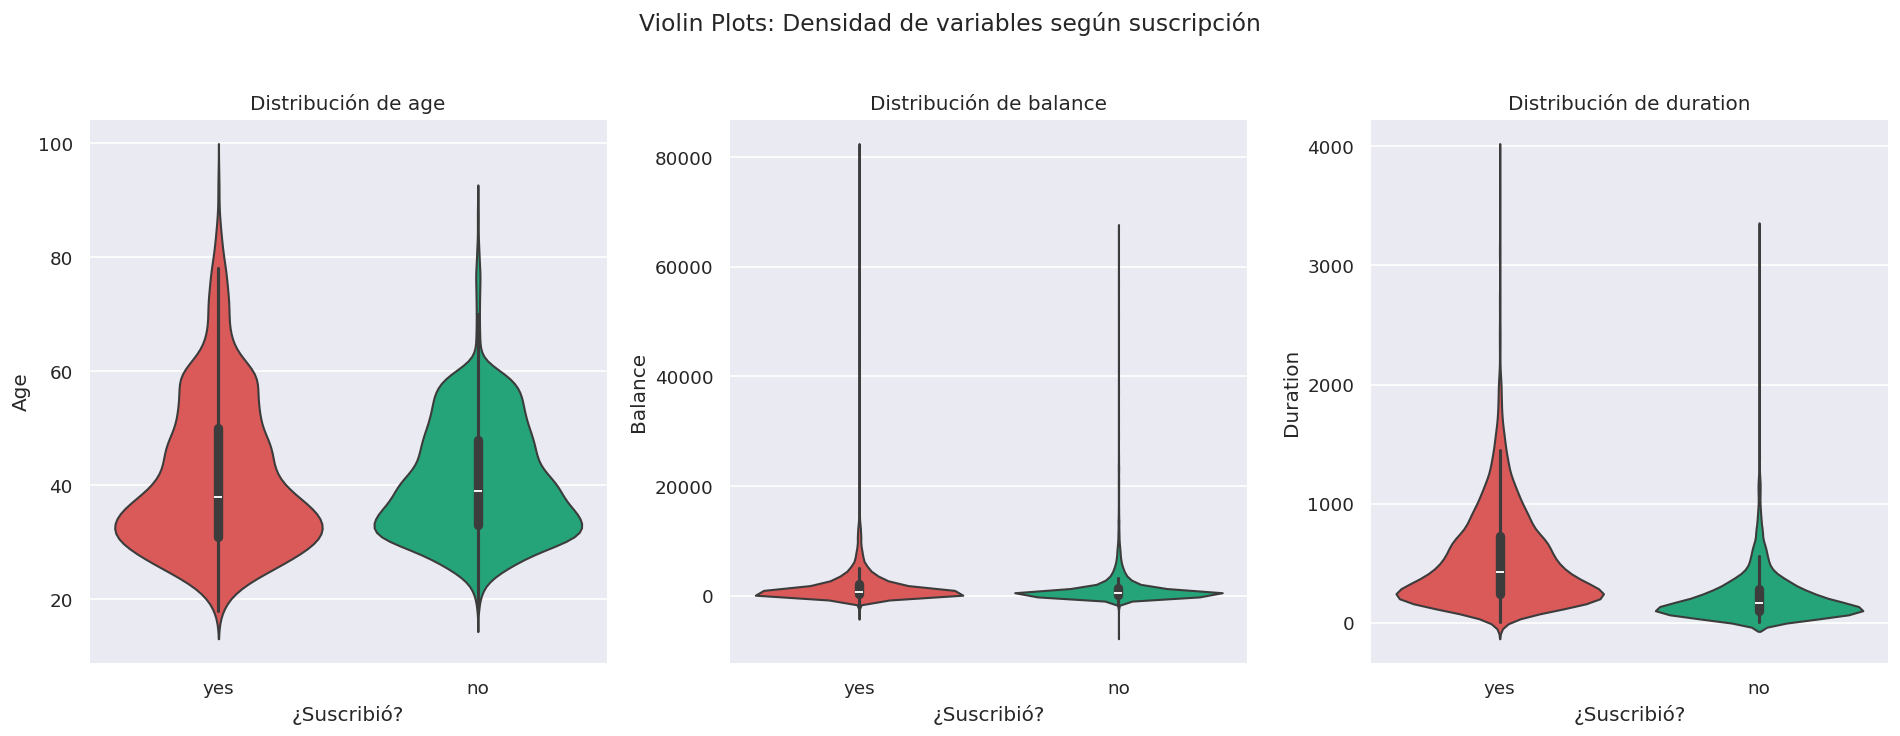

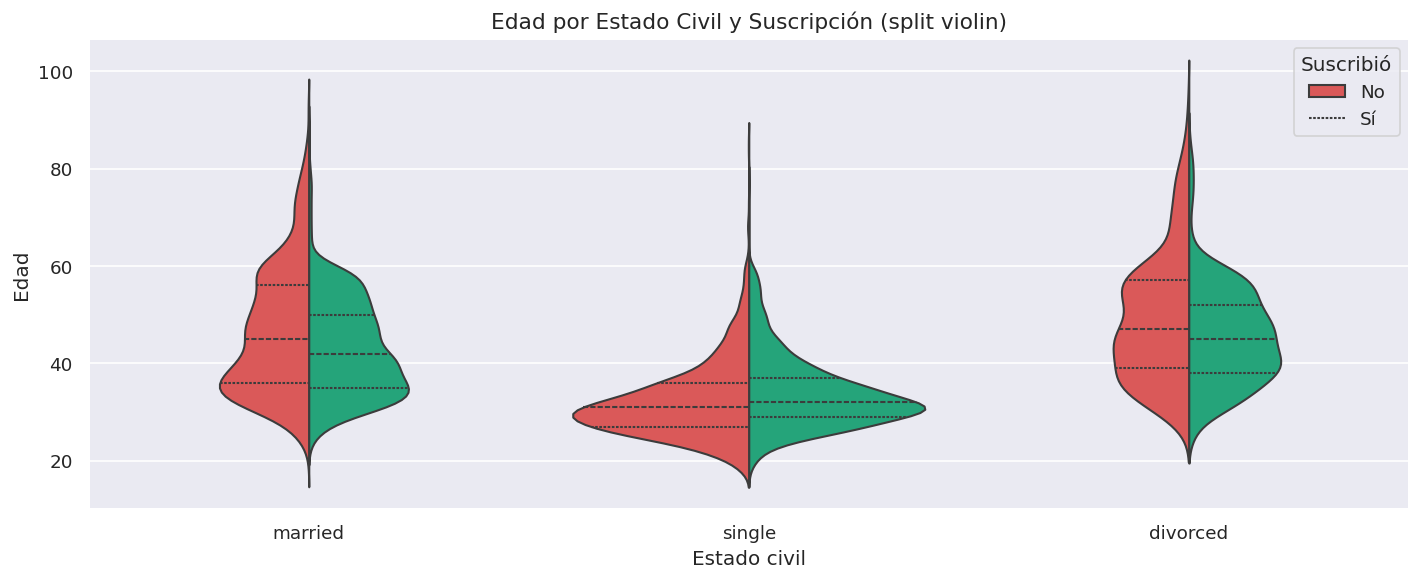

In [ ]:
# Violin plots: variables numéricas según suscripción
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

vars_violin = ['age', 'balance', 'duration']

for i, var in enumerate(vars_violin):
    sns.violinplot(
        data=df, x='deposit', y=var,
        palette=['#ef4444', '#10b981'],
        inner='box',  # muestra el box dentro del violín
        ax=axes[i]
    )
    axes[i].set_title(f'Distribución de {var}', fontsize=12)
    axes[i].set_xlabel('¿Suscribió?')
    axes[i].set_ylabel(var.capitalize())

plt.suptitle('Violin Plots: Densidad de variables según suscripción',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Violin adicional: age por estado civil y suscripción
plt.figure(figsize=(12, 5))
sns.violinplot(data=df, x='marital', y='age',
               hue='deposit', split=True,
               palette=['#ef4444', '#10b981'], inner='quart')
plt.title('Edad por Estado Civil y Suscripción (split violin)', fontsize=13)
plt.xlabel('Estado civil')
plt.ylabel('Edad')
plt.legend(title='Suscribió', labels=['No', 'Sí'])
plt.tight_layout()
plt.show()

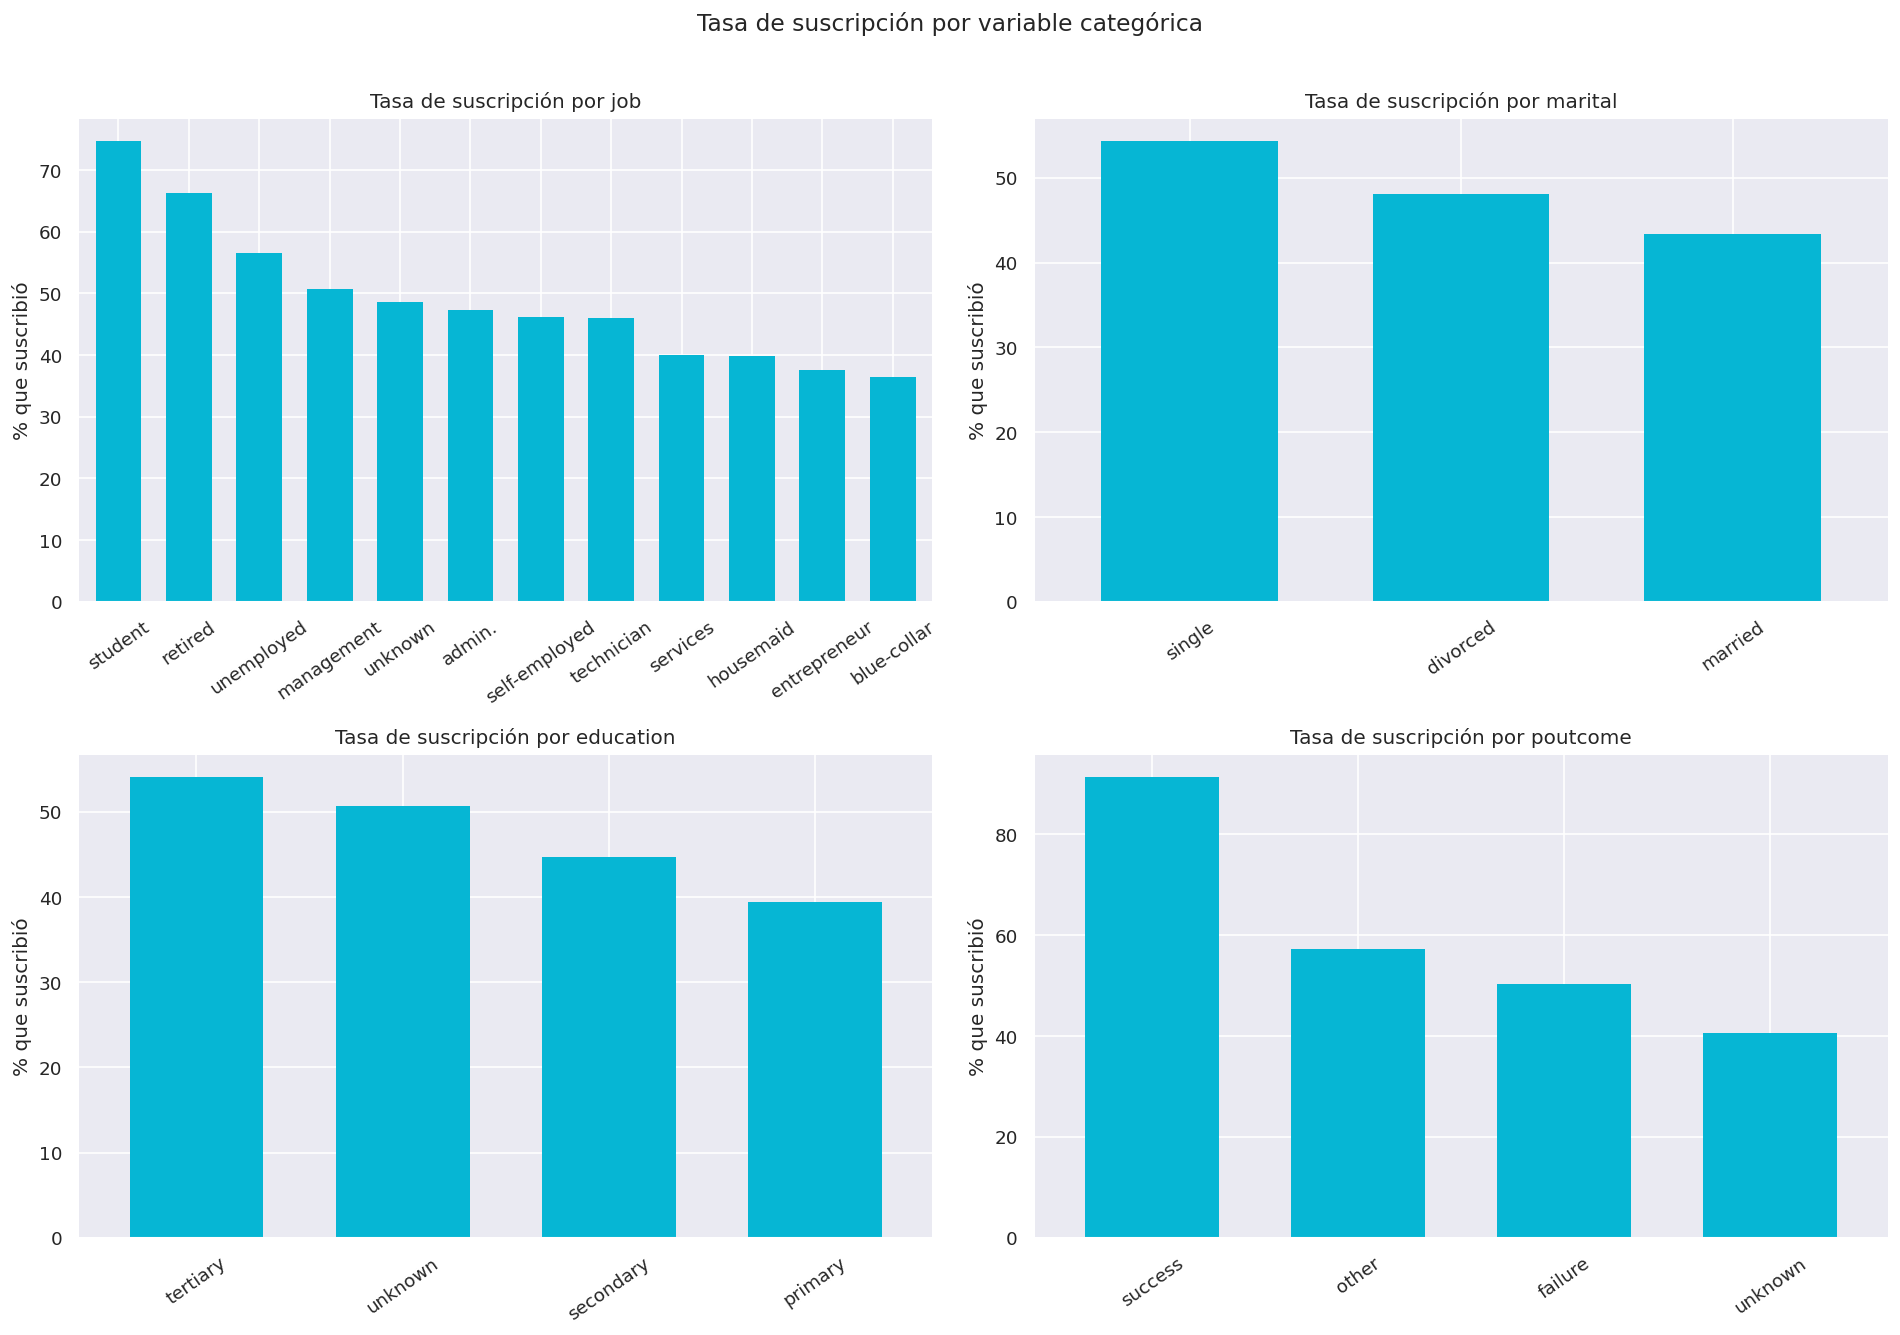

In [ ]:
# Tasa de suscripción por variable categórica
cats = ['job', 'marital', 'education', 'poutcome']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for i, cat in enumerate(cats):
    # Calcular tasa de suscripción por categoría
    tasa = df.groupby(cat)['deposit'].apply(
        lambda x: (x == 'yes').mean() * 100
    ).sort_values(ascending=False)

    tasa.plot(kind='bar', ax=axes[i], color='#06b6d4',
              edgecolor='none', width=0.65)
    axes[i].set_title(f'Tasa de suscripción por {cat}', fontsize=12)
    axes[i].set_ylabel('% que suscribió')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=35)

plt.suptitle('Tasa de suscripción por variable categórica', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

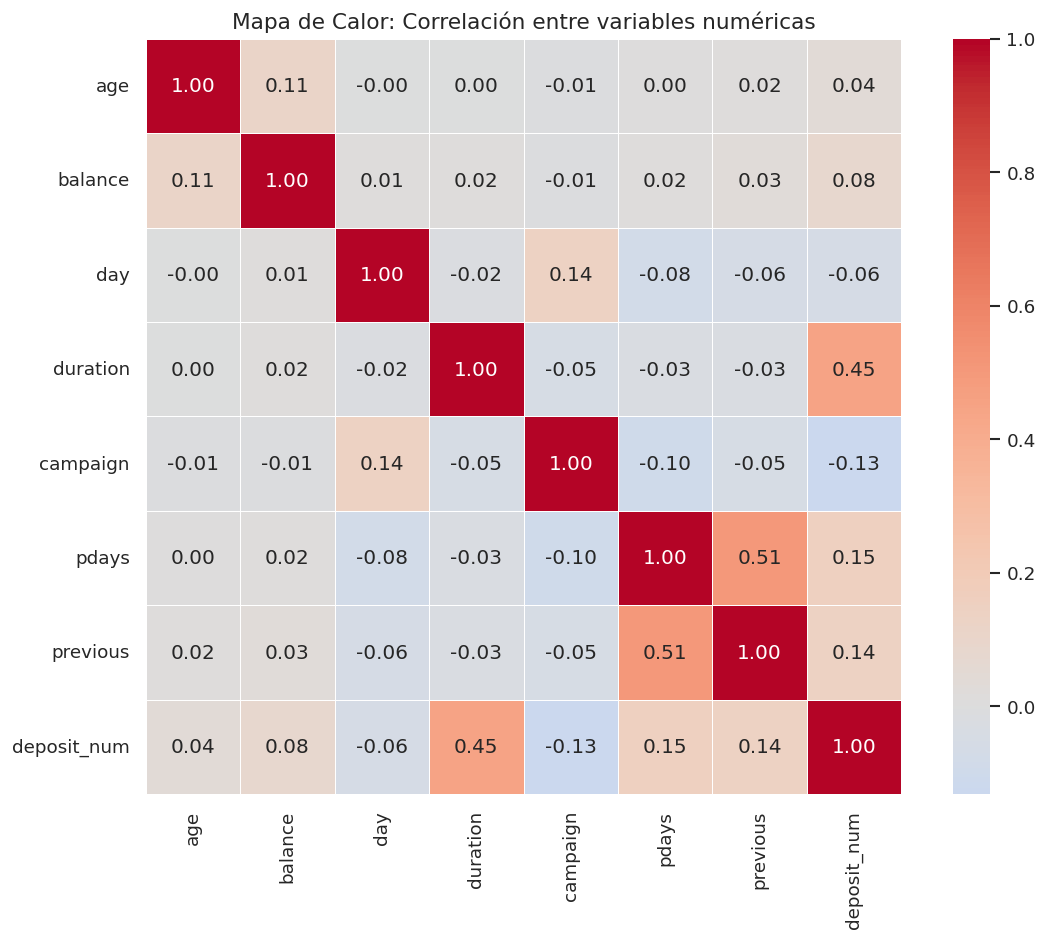

Correlación con 'deposit' (ordenada):
deposit_num    1.000
duration       0.451
pdays          0.152
previous       0.140
balance        0.081
age            0.035
day           -0.056
campaign      -0.132
Name: deposit_num, dtype: float64


In [ ]:
# Codificamos temporalmente 'deposit' para incluirla en la correlación
df_temp = df.copy()
df_temp['deposit_num'] = (df_temp['deposit'] == 'yes').astype(int)

# Seleccionar solo columnas numéricas
num_cols = df_temp.select_dtypes(include=['number']).columns
corr = df_temp[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, square=True
)
plt.title('Mapa de Calor: Correlación entre variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

# Correlaciones con la variable objetivo ordenadas
print("Correlación con 'deposit' (ordenada):")
print(corr['deposit_num'].sort_values(ascending=False).round(3))

In [ ]:
# Análisis completo de nulos
print("=== Valores nulos por columna ===")
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({
    'Nulos': nulos, 'Porcentaje (%)': pct_nulos
}).query('Nulos > 0')
print(resumen_nulos if len(resumen_nulos) > 0 else "✅ Sin valores nulos")

# Imputar numéricas con mediana
cols_num = df.select_dtypes(include='number').columns
for col in cols_num:
    if df[col].isnull().sum() > 0:
        mediana = df[col].median()
        df[col].fillna(mediana, inplace=True)
        print(f"  '{col}' → imputado con mediana: {mediana}")

print(f"\nNulos restantes: {df.isnull().sum().sum()}")
print(f"Shape del dataset: {df.shape}")

=== Valores nulos por columna ===
          Nulos  Porcentaje (%)
age         334            2.99
duration    558            5.00
campaign   1116           10.00
  'age' → imputado con mediana: 39.0
  'duration' → imputado con mediana: 255.0
  'campaign' → imputado con mediana: 2.0

Nulos restantes: 0
Shape del dataset: (11162, 17)


In [ ]:
# Codificar todas las columnas categóricas con Label Encoding
le = LabelEncoder()

cols_cat = df.select_dtypes(include='object').columns.tolist()
print(f"Columnas a codificar: {cols_cat}\n")

# Guardamos el mapeo para poder interpretarlo después
mapeos = {}

for col in cols_cat:
    df[col] = le.fit_transform(df[col].astype(str))
    mapeos[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"  '{col}' → {mapeos[col]}")

print("\n✅ Encoding completado")
print(f"Tipos de datos resultantes:\n{df.dtypes}")

Columnas a codificar: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']

  'job' → {'admin.': np.int64(0), 'blue-collar': np.int64(1), 'entrepreneur': np.int64(2), 'housemaid': np.int64(3), 'management': np.int64(4), 'retired': np.int64(5), 'self-employed': np.int64(6), 'services': np.int64(7), 'student': np.int64(8), 'technician': np.int64(9), 'unemployed': np.int64(10), 'unknown': np.int64(11)}
  'marital' → {'divorced': np.int64(0), 'married': np.int64(1), 'single': np.int64(2)}
  'education' → {'primary': np.int64(0), 'secondary': np.int64(1), 'tertiary': np.int64(2), 'unknown': np.int64(3)}
  'default' → {'no': np.int64(0), 'yes': np.int64(1)}
  'housing' → {'no': np.int64(0), 'yes': np.int64(1)}
  'loan' → {'no': np.int64(0), 'yes': np.int64(1)}
  'contact' → {'cellular': np.int64(0), 'telephone': np.int64(1), 'unknown': np.int64(2)}
  'month' → {'apr': np.int64(0), 'aug': np.int64(1), 'dec': np.int64(2), 'feb': np.int64(3), 

In [ ]:
# Separar features (X) y target (y) ANTES de escalar
y = df['deposit'].copy()
X = df.drop(columns=['deposit'])

# Escalar solo las columnas numéricas relevantes
cols_escalar = ['age', 'balance', 'duration',
                'campaign', 'pdays', 'previous', 'day']

scaler = StandardScaler()
X[cols_escalar] = scaler.fit_transform(X[cols_escalar])

print("✅ Escalado completado")
print(f"\nEjemplo — 'age' después del escalado:")
print(f"  Media: {X['age'].mean():.4f} (esperado: ~0)")
print(f"  Std:   {X['age'].std():.4f}  (esperado: ~1)")

# Verificación final
print(f"\nShape final de X: {X.shape}")
print(f"Valores nulos en X: {X.isnull().sum().sum()}")
X.head(3)

✅ Escalado completado

Ejemplo — 'age' después del escalado:
  Media: -0.0000 (esperado: ~0)
  Std:   1.0000  (esperado: ~1)

Shape final de X: (11162, 16)
Valores nulos en X: 0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,1.523363,0,1,1,0,0.252525,1,0,2,-1.265746,8,1.984820,-0.566428,-0.481184,-0.36326,3
1,1.267428,0,1,1,0,-0.459974,0,0,2,-1.265746,8,-0.328618,-0.566428,-0.481184,-0.36326,3
2,-0.012244,9,1,1,0,-0.080160,1,0,2,-1.265746,8,3.004849,-0.566428,-0.481184,-0.36326,3


In [ ]:
# Todas las features disponibles (después del encoding)
features = [
    'age', 'job', 'marital', 'education', 'default',
    'balance', 'housing', 'loan', 'contact', 'day',
    'month', 'duration', 'campaign', 'pdays',
    'previous', 'poutcome'
]

X = df[features]
y = df['deposit']

print(f"✅ Features seleccionadas: {len(features)}")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")
print(f"   Clases en y: {y.unique()}")
print(f"   Balance de clases: {y.value_counts().to_dict()}")

✅ Features seleccionadas: 16
   X shape: (11162, 16)
   y shape: (11162,)
   Clases en y: [1 0]
   Balance de clases: {0: 5873, 1: 5289}


In [ ]:
# División estratificada: mantiene la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # ← fundamental para datos de clasificación
)

print("=== División del dataset ===")
print(f"X_train: {X_train.shape[0]:,} filas")
print(f"X_test:  {X_test.shape[0]:,} filas")

print("\n=== Verificación de balance de clases ===")
print(f"Train — suscribió: {y_train.mean()*100:.1f}%")
print(f"Test  — suscribió: {y_test.mean()*100:.1f}%")
print(f"Total — suscribió: {y.mean()*100:.1f}%")
# Los tres valores deben ser similares (~47%)

=== División del dataset ===
X_train: 8,929 filas
X_test:  2,233 filas

=== Verificación de balance de clases ===
Train — suscribió: 47.4%
Test  — suscribió: 47.4%
Total — suscribió: 47.4%


In [ ]:
# ============================================
# MODELO 1: Regresión Logística
# ============================================
rl = LogisticRegression(
    max_iter=1000,     # iteraciones suficientes para converger
    random_state=42,
    C=1.0             # regularización (mayor C = menos regularización)
)

# Entrenamiento
rl.fit(X_train, y_train)

# Predicciones
y_pred_rl = rl.predict(X_test)
y_prob_rl = rl.predict_proba(X_test)[:, 1]  # probabilidad de clase 1

print("✅ Regresión Logística entrenada")
print(f"   Iteraciones hasta convergencia: {rl.n_iter_[0]}")

✅ Regresión Logística entrenada
   Iteraciones hasta convergencia: 1000


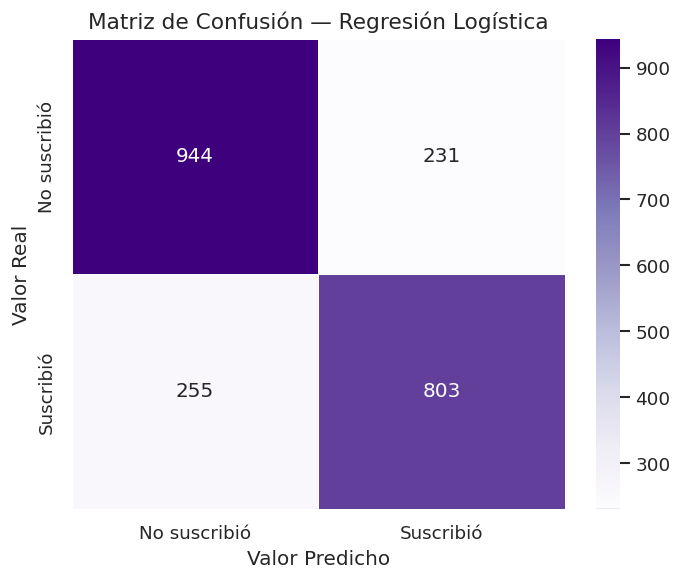

TN=944  FP=231  FN=255  TP=803


In [ ]:
# Calcular y graficar la Matriz de Confusión — Regresión Logística
cm_rl = confusion_matrix(y_test, y_pred_rl)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rl, annot=True, fmt='d', cmap='Purples',
    xticklabels=['No suscribió', 'Suscribió'],
    yticklabels=['No suscribió', 'Suscribió'],
    linewidths=0.5
)
plt.title('Matriz de Confusión — Regresión Logística', fontsize=13)
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm_rl.ravel()
print(f"TN={TN}  FP={FP}  FN={FN}  TP={TP}")

In [ ]:
# Métricas completas
acc_rl = accuracy_score(y_test, y_pred_rl)
auc_rl = roc_auc_score(y_test, y_prob_rl)

print("=== Regresión Logística — Métricas ===")
print(f"Accuracy:  {acc_rl:.4f} ({acc_rl*100:.2f}%)")
print(f"AUC-ROC:   {auc_rl:.4f}")
print("\n" + classification_report(
    y_test, y_pred_rl,
    target_names=['No suscribió', 'Suscribió']
))

=== Regresión Logística — Métricas ===
Accuracy:  0.7824 (78.24%)
AUC-ROC:   0.8615

              precision    recall  f1-score   support

No suscribió       0.79      0.80      0.80      1175
   Suscribió       0.78      0.76      0.77      1058

    accuracy                           0.78      2233
   macro avg       0.78      0.78      0.78      2233
weighted avg       0.78      0.78      0.78      2233



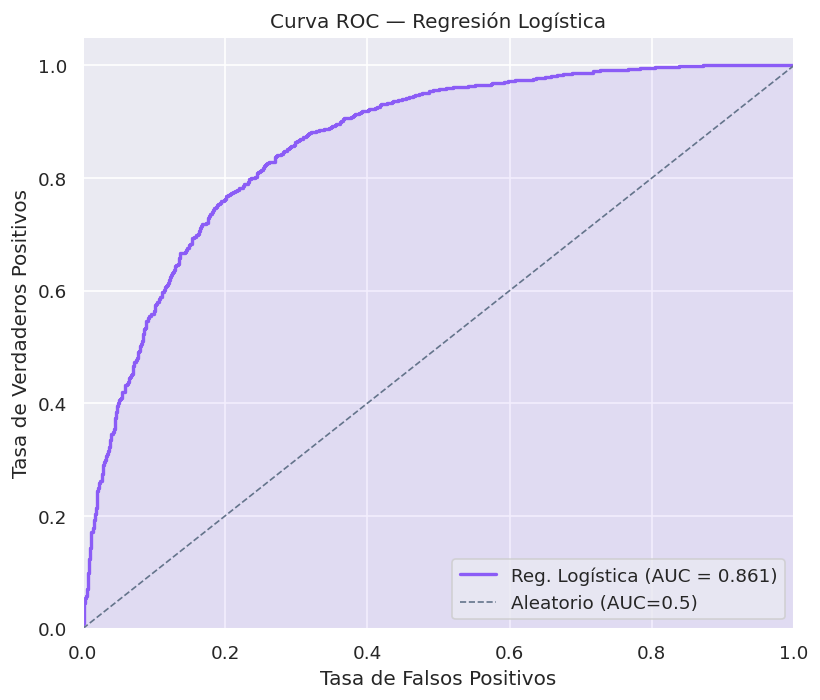

In [ ]:
# Curva ROC del modelo de Regresión Logística
fpr_rl, tpr_rl, _ = roc_curve(y_test, y_prob_rl)

plt.figure(figsize=(7, 6))
plt.plot(fpr_rl, tpr_rl, color='#8b5cf6', lw=2,
         label=f'Reg. Logística (AUC = {auc_rl:.3f})')
plt.plot([0,1],[0,1], '--', color='#64748b', lw=1, label='Aleatorio (AUC=0.5)')
plt.fill_between(fpr_rl, tpr_rl, alpha=0.1, color='#8b5cf6')
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC — Regresión Logística')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# MODELO 2: Random Forest
# ============================================
rf = RandomForestClassifier(
    n_estimators=200,    # 200 árboles
    max_depth=None,      # árboles sin límite de profundidad
    min_samples_split=2,
    max_features='sqrt', # raíz cuadrada de features por split
    random_state=42,
    n_jobs=-1           # usar todos los núcleos disponibles
)

# Entrenamiento
rf.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("✅ Random Forest entrenado")
print(f"   Árboles entrenados: {rf.n_estimators}")
print(f"   Features usadas:    {rf.n_features_in_}")

✅ Random Forest entrenado
   Árboles entrenados: 200
   Features usadas:    16


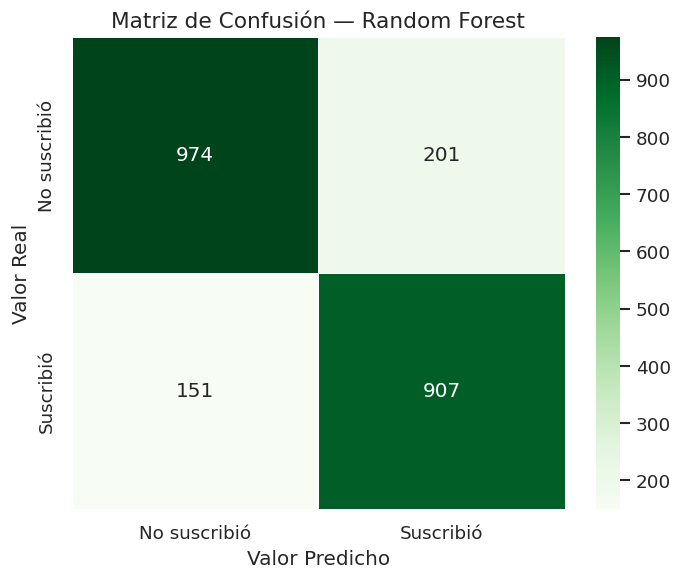

TN=974  FP=201  FN=151  TP=907


In [ ]:
# Calcular y graficar la Matriz de Confusión — Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf, annot=True, fmt='d', cmap='Greens',
    xticklabels=['No suscribió', 'Suscribió'],
    yticklabels=['No suscribió', 'Suscribió'],
    linewidths=0.5
)
plt.title('Matriz de Confusión — Random Forest', fontsize=13)
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm_rf.ravel()
print(f"TN={TN}  FP={FP}  FN={FN}  TP={TP}")

In [ ]:
# Métricas completas del Random Forest
acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("=== Random Forest — Métricas ===")
print(f"Accuracy:  {acc_rf:.4f} ({acc_rf*100:.2f}%)")
print(f"AUC-ROC:   {auc_rf:.4f}")
print("\n" + classification_report(
    y_test, y_pred_rf,
    target_names=['No suscribió', 'Suscribió']
))

=== Random Forest — Métricas ===
Accuracy:  0.8424 (84.24%)
AUC-ROC:   0.9110

              precision    recall  f1-score   support

No suscribió       0.87      0.83      0.85      1175
   Suscribió       0.82      0.86      0.84      1058

    accuracy                           0.84      2233
   macro avg       0.84      0.84      0.84      2233
weighted avg       0.84      0.84      0.84      2233



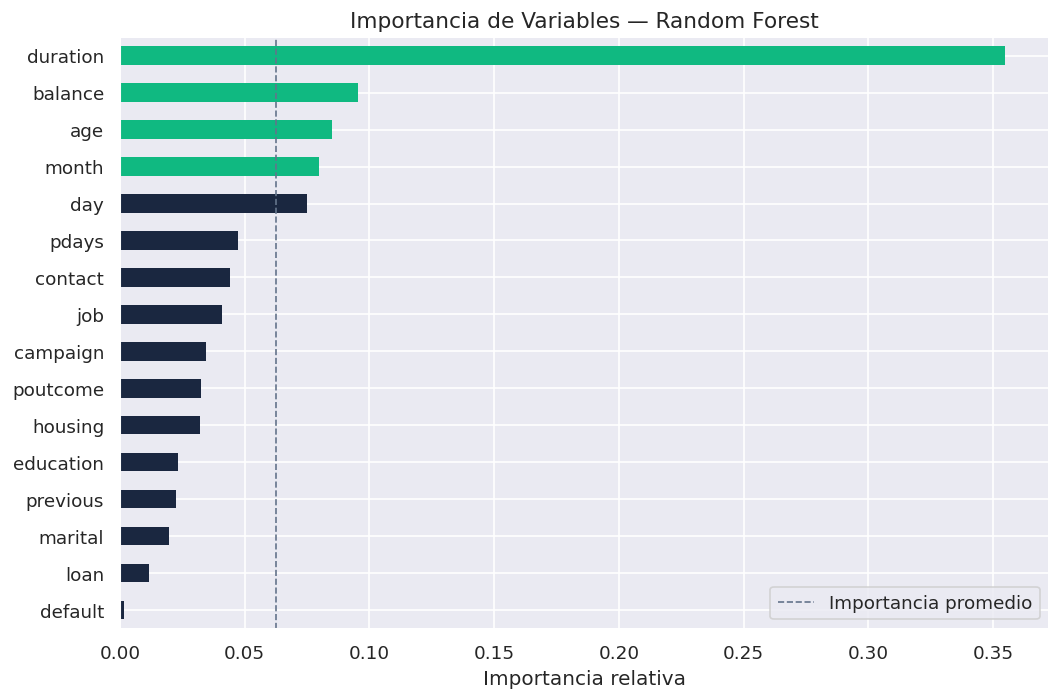

Top 5 variables más importantes:
duration    0.3546
balance     0.0952
age         0.0852
month       0.0800
day         0.0750
dtype: float64


In [ ]:
# Importancia de variables según el Random Forest
importancias = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colores = ['#10b981' if v >= importancias.quantile(0.75)
           else '#1a2740' for v in importancias]
importancias.plot(kind='barh', color=colores, edgecolor='none')
plt.title('Importancia de Variables — Random Forest', fontsize=13)
plt.xlabel('Importancia relativa')
plt.axvline(x=1/len(importancias), color='#64748b',
            linestyle='--', lw=1, label='Importancia promedio')
plt.legend()
plt.tight_layout()
plt.show()

print("Top 5 variables más importantes:")
print(importancias.sort_values(ascending=False).head(5).round(4))

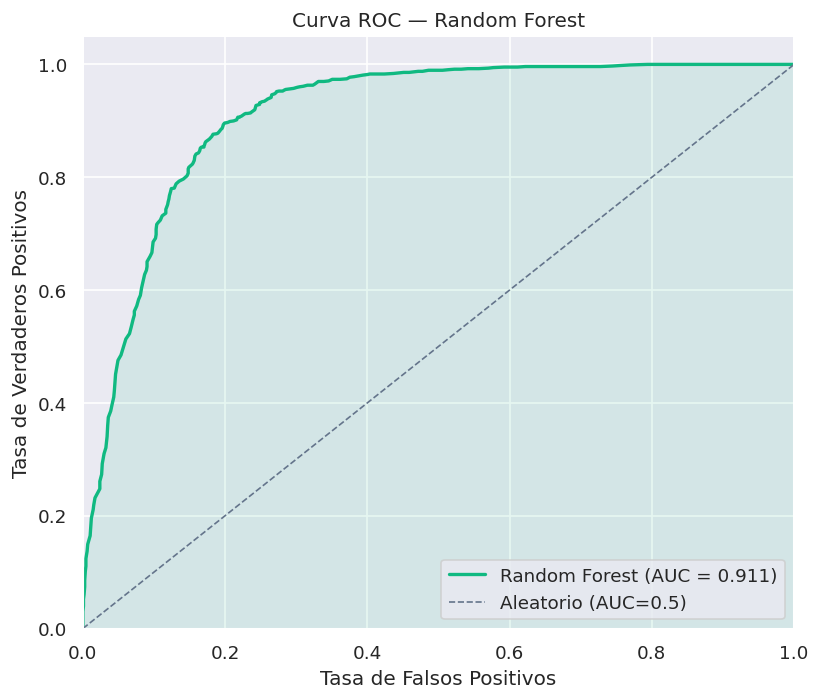

In [ ]:
# Curva ROC del Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7, 6))
plt.plot(fpr_rf, tpr_rf, color='#10b981', lw=2,
         label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0,1],[0,1], '--', color='#64748b', lw=1, label='Aleatorio (AUC=0.5)')
plt.fill_between(fpr_rf, tpr_rf, alpha=0.1, color='#10b981')
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC — Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# Tabla resumen de ambos modelos
resumen = pd.DataFrame({
    'Modelo':   ['Regresión Logística', 'Random Forest'],
    'Accuracy': [round(acc_rl, 4), round(acc_rf, 4)],
    'AUC-ROC':  [round(auc_rl, 4), round(auc_rf, 4)],
})

print("=== Comparativa de Modelos ===")
print(resumen.to_string(index=False))

mejor = resumen.loc[resumen['AUC-ROC'].idxmax(), 'Modelo']
print(f"\n🏆 Mejor modelo por AUC-ROC: {mejor}")

=== Comparativa de Modelos ===
             Modelo  Accuracy  AUC-ROC
Regresión Logística    0.7824   0.8615
      Random Forest    0.8424   0.9110

🏆 Mejor modelo por AUC-ROC: Random Forest


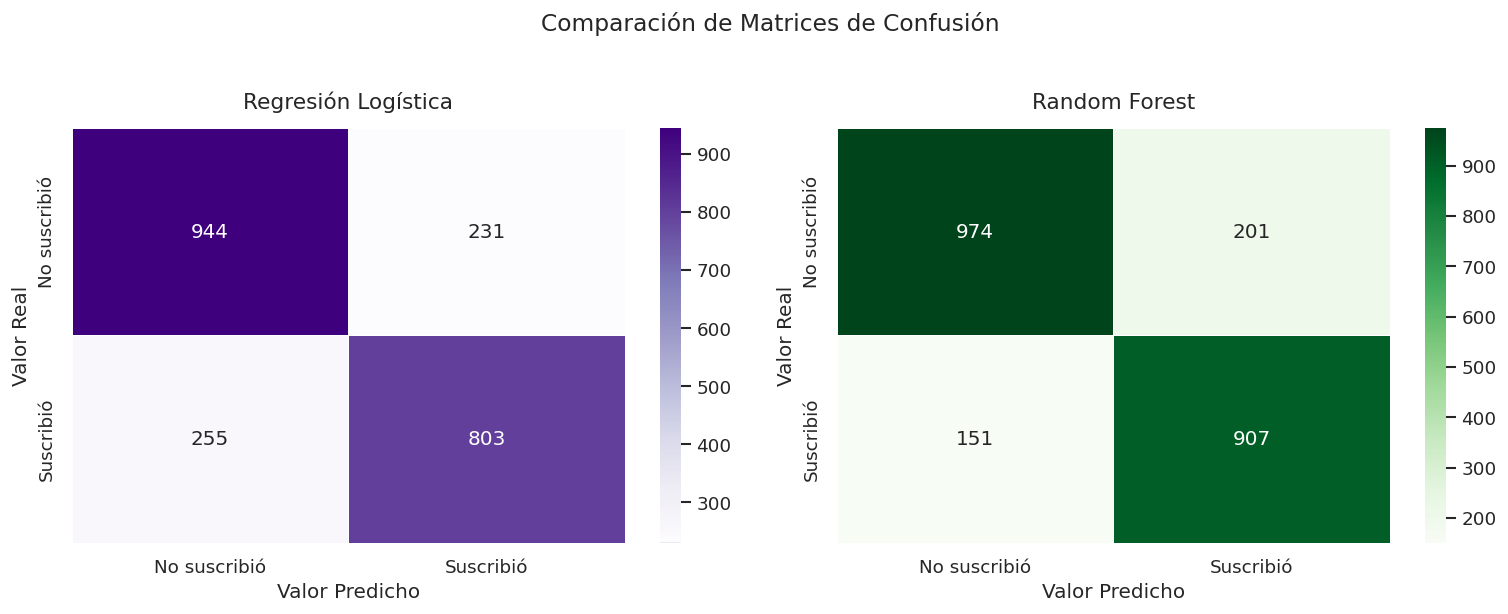

In [ ]:
# Matrices de confusión de ambos modelos en una sola figura
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels = ['No suscribió', 'Suscribió']

# Regresión Logística
sns.heatmap(cm_rl, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Regresión Logística', fontsize=13, pad=12)
axes[0].set_ylabel('Valor Real')
axes[0].set_xlabel('Valor Predicho')

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Random Forest', fontsize=13, pad=12)
axes[1].set_ylabel('Valor Real')
axes[1].set_xlabel('Valor Predicho')

plt.suptitle('Comparación de Matrices de Confusión', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

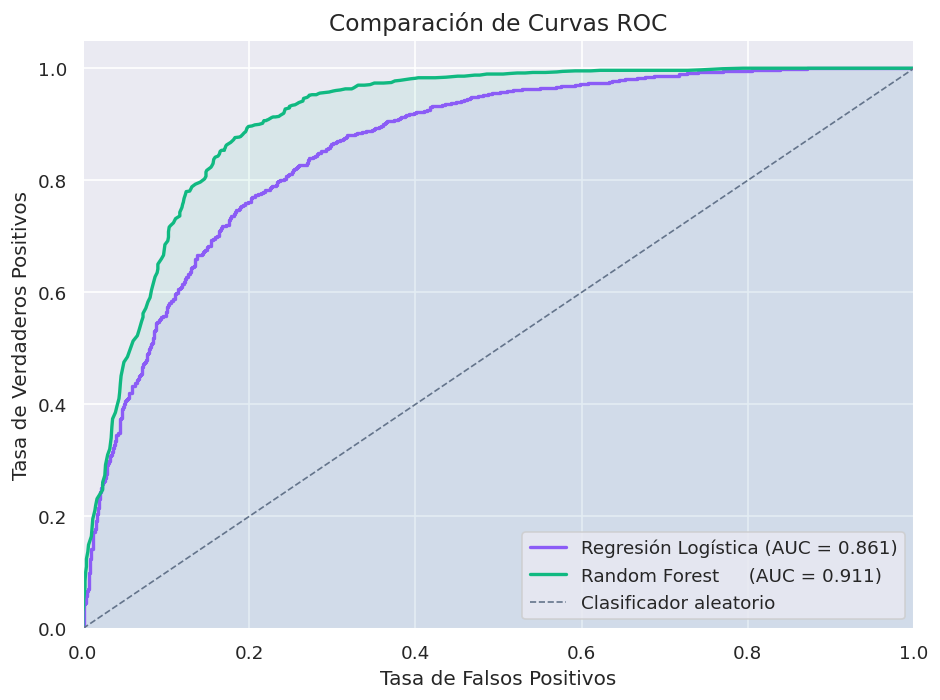

In [ ]:
# Curvas ROC superpuestas de ambos modelos
plt.figure(figsize=(8, 6))

plt.plot(fpr_rl, tpr_rl, color='#8b5cf6', lw=2,
         label=f'Regresión Logística (AUC = {auc_rl:.3f})')
plt.fill_between(fpr_rl, tpr_rl, alpha=0.08, color='#8b5cf6')

plt.plot(fpr_rf, tpr_rf, color='#10b981', lw=2,
         label=f'Random Forest     (AUC = {auc_rf:.3f})')
plt.fill_between(fpr_rf, tpr_rf, alpha=0.08, color='#10b981')

plt.plot([0,1],[0,1], '--', color='#64748b', lw=1, label='Clasificador aleatorio')

plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.xlabel('Tasa de Falsos Positivos', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos', fontsize=12)
plt.title('Comparación de Curvas ROC', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

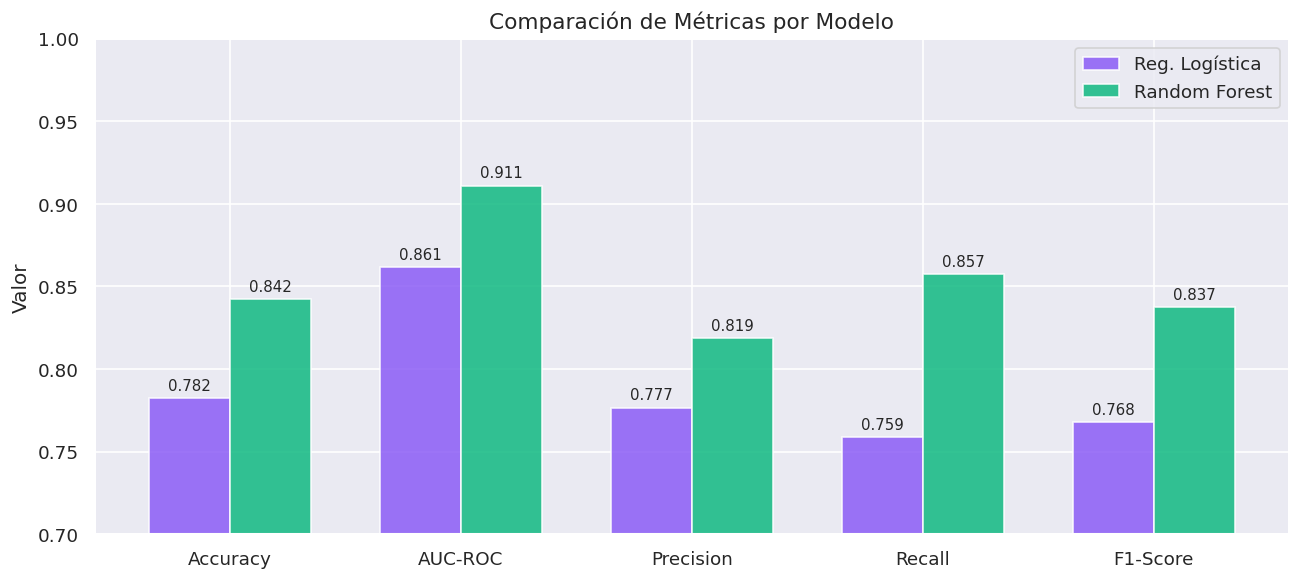

In [ ]:
# Comparación visual de todas las métricas clave
from sklearn.metrics import precision_score, recall_score, f1_score

metricas = {
    'Accuracy':  [acc_rl, acc_rf],
    'AUC-ROC':   [auc_rl, auc_rf],
    'Precision': [precision_score(y_test, y_pred_rl),
                  precision_score(y_test, y_pred_rf)],
    'Recall':    [recall_score(y_test, y_pred_rl),
                  recall_score(y_test, y_pred_rf)],
    'F1-Score':  [f1_score(y_test, y_pred_rl),
                  f1_score(y_test, y_pred_rf)],
}

x = np.arange(len(metricas))
ancho = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars_rl = ax.bar(x - ancho/2, [v[0] for v in metricas.values()],
                  ancho, label='Reg. Logística', color='#8b5cf6', alpha=0.85)
bars_rf = ax.bar(x + ancho/2, [v[1] for v in metricas.values()],
                  ancho, label='Random Forest', color='#10b981', alpha=0.85)

ax.set_ylabel('Valor'); ax.set_title('Comparación de Métricas por Modelo', fontsize=13)
ax.set_xticks(x); ax.set_xticklabels(metricas.keys())
ax.set_ylim(0.7, 1.0); ax.legend()
ax.bar_label(bars_rl, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(bars_rf, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ================================================
# RESUMEN FINAL DEL PROYECTO
# ================================================
print("=" * 55)
print("   TRABAJO FINAL ICD 2026 — BANK MARKETING")
print("=" * 55)
print(f"\n📦 Dataset:")
print(f"   Total registros: {len(df):,}")
print(f"   Features usadas: {X.shape[1]}")
print(f"\n🔀 División:")
print(f"   Train: {len(X_train):,} filas (80%)")
print(f"   Test:  {len(X_test):,} filas (20%)")
print(f"\n📊 Resultados:")
print(f"   {'Modelo':<22} {'Accuracy':>10} {'AUC-ROC':>10}")
print(f"   {'-'*44}")
print(f"   {'Regresión Logística':<22} {acc_rl*100:>9.2f}% {auc_rl:>10.4f}")
print(f"   {'Random Forest':<22} {acc_rf*100:>9.2f}% {auc_rf:>10.4f}")
print(f"\n🏆 Mejor modelo: Random Forest")
print(f"   Mejora en Accuracy: +{(acc_rf-acc_rl)*100:.2f}pp")
print(f"   Mejora en AUC-ROC:  +{(auc_rf-auc_rl):.4f}")
print("=" * 55)

   TRABAJO FINAL ICD 2026 — BANK MARKETING

📦 Dataset:
   Total registros: 11,162
   Features usadas: 16

🔀 División:
   Train: 8,929 filas (80%)
   Test:  2,233 filas (20%)

📊 Resultados:
   Modelo                   Accuracy    AUC-ROC
   --------------------------------------------
   Regresión Logística        78.24%     0.8615
   Random Forest              84.24%     0.9110

🏆 Mejor modelo: Random Forest
   Mejora en Accuracy: +6.00pp
   Mejora en AUC-ROC:  +0.0496
